In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [5]:
# Load the CSV files
df1 = pd.read_csv("csvs/results_19103.csv")
df2 = pd.read_csv("csvs/results_25274.csv")
df3 = pd.read_csv("csvs/results_47580.csv")

df = pd.concat([df1, df2, df3], ignore_index=True)

In [6]:
df.head(15)

,file,type,dataset,detected_count,time_ns,first_x,first_y,first_w,first_h
0,1187019.jpg,Brazil,DS1,1,145228400,2352,1466,632,158
1,1187019_labelled.jpg,Brazil,DS1,1,139617800,1988,1568,179,45
2,1792023.jpg,Brazil,DS1,1,130486700,1532,1202,167,42
3,1792023_labelled.jpg,Brazil,DS1,1,131657700,1532,1202,167,42
4,2114000.jpg,Brazil,DS1,4,122671400,3507,1339,246,62
5,2114000_labelled.jpg,Brazil,DS1,3,107001300,3510,1344,243,61
6,2148000.jpg,Brazil,DS1,0,107955400,0,0,0,0
7,2148000_labelled.jpg,Brazil,DS1,1,122481400,1470,1992,192,48
8,2154018.jpg,Brazil,DS1,0,113096000,0,0,0,0
9,2154018_labelled.jpg,Brazil,DS1,1,119489200,994,1224,243,61


In [7]:
sns.set(style="whitegrid")

In [8]:
df['dataset'] = df['dataset'].astype('category')
df['type'] = df['type'].astype('category')

df['time_ns'] = pd.to_numeric(df['time_ns'], errors='coerce')
df['detected_count'] = pd.to_numeric(df['detected_count'], errors='coerce')

In [9]:
print("\n=== Estatísticas Descritivas ===")
print(df.describe())


=== Estatísticas Descritivas ===
       detected_count       time_ns       first_x       first_y       first_w  \
count    16740.000000  1.674000e+04  16740.000000  16740.000000  16740.000000   
mean         0.197133  1.757095e+07     87.516547     72.952449     27.397730   
std          0.844908  4.240200e+07    362.261522    282.472153     82.964011   
min          0.000000  3.421000e+05      0.000000      0.000000      0.000000   
25%          0.000000  2.239525e+06      0.000000      0.000000      0.000000   
50%          0.000000  6.040500e+06      0.000000      0.000000      0.000000   
75%          0.000000  1.399170e+07      0.000000      0.000000      0.000000   
max         30.000000  7.212153e+08   5204.000000   4163.000000   1119.000000   

            first_h  
count  16740.000000  
mean       6.846774  
std       20.743225  
min        0.000000  
25%        0.000000  
50%        0.000000  
75%        0.000000  
max      280.000000  


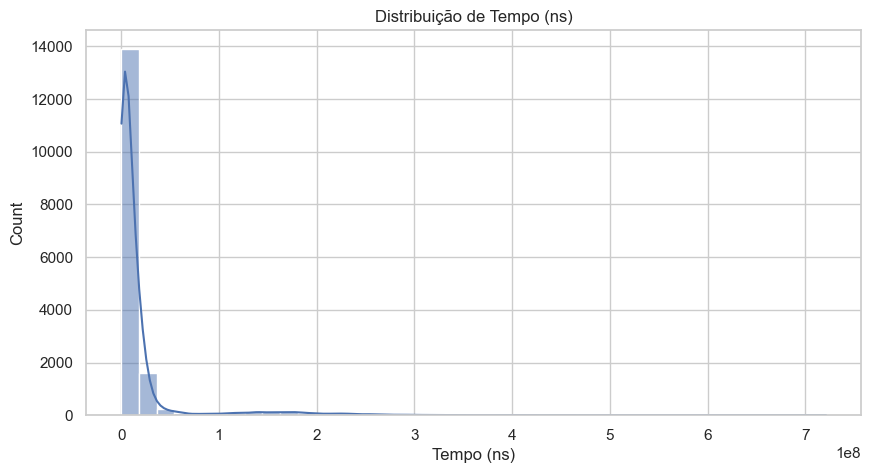

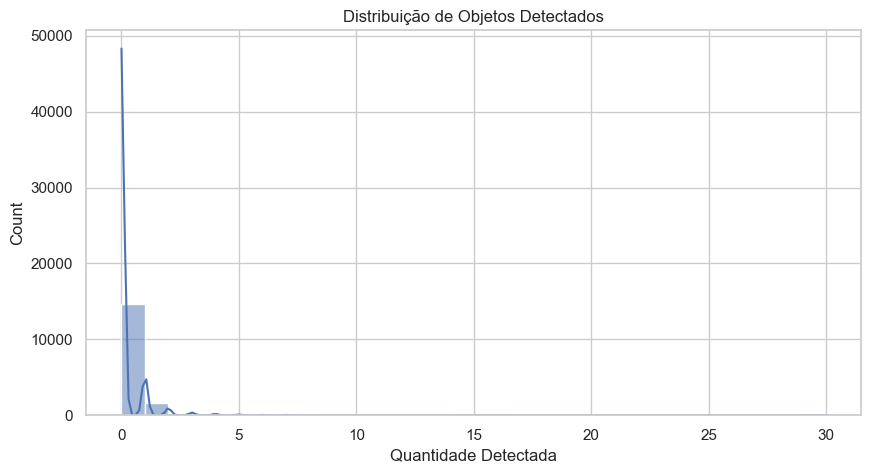

In [10]:
# Histograma do tempo
plt.figure(figsize=(10,5))
sns.histplot(df['time_ns'], kde=True, bins=40)
plt.title("Distribuição de Tempo (ns)")
plt.xlabel("Tempo (ns)")
plt.show()

# Histograma da quantidade detectada
plt.figure(figsize=(10,5))
sns.histplot(df['detected_count'], kde=True, bins=30)
plt.title("Distribuição de Objetos Detectados")
plt.xlabel("Quantidade Detectada")
plt.show()


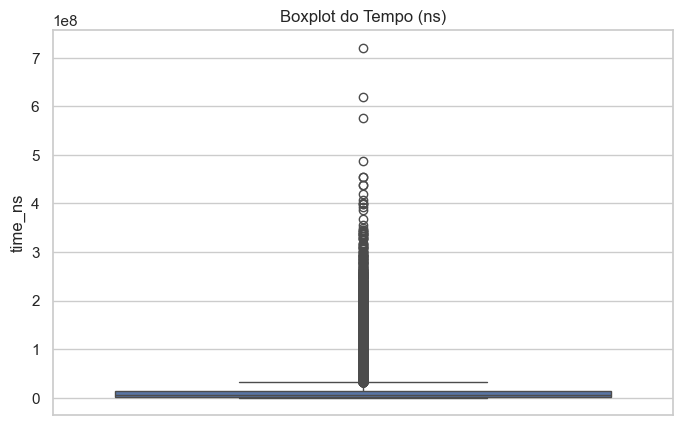

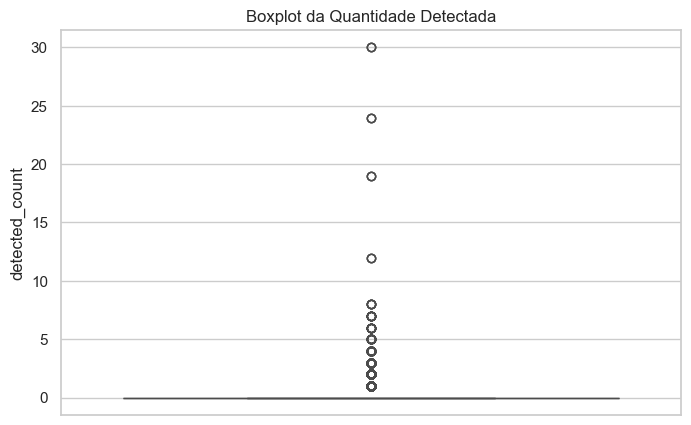

In [11]:
plt.figure(figsize=(8,5))
sns.boxplot(y=df['time_ns'])
plt.title("Boxplot do Tempo (ns)")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(y=df['detected_count'])
plt.title("Boxplot da Quantidade Detectada")
plt.show()


C:\Users\maria\AppData\Local\Temp\ipykernel_19736\892988395.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df['time_ns'], shade=True)


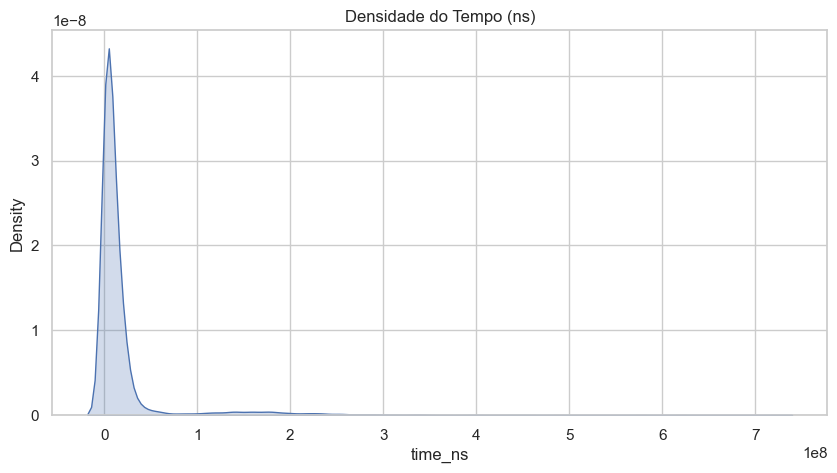

C:\Users\maria\AppData\Local\Temp\ipykernel_19736\892988395.py:7: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df['detected_count'], shade=True)


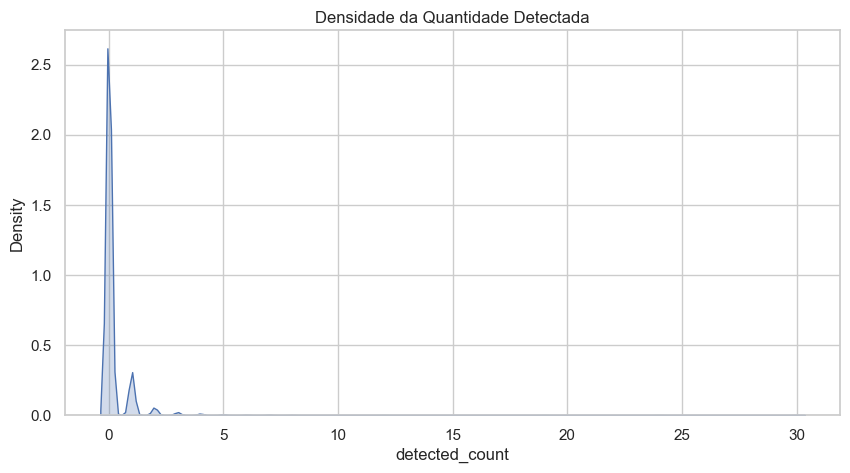

In [12]:
plt.figure(figsize=(10,5))
sns.kdeplot(df['time_ns'], shade=True)
plt.title("Densidade do Tempo (ns)")
plt.show()

plt.figure(figsize=(10,5))
sns.kdeplot(df['detected_count'], shade=True)
plt.title("Densidade da Quantidade Detectada")
plt.show()


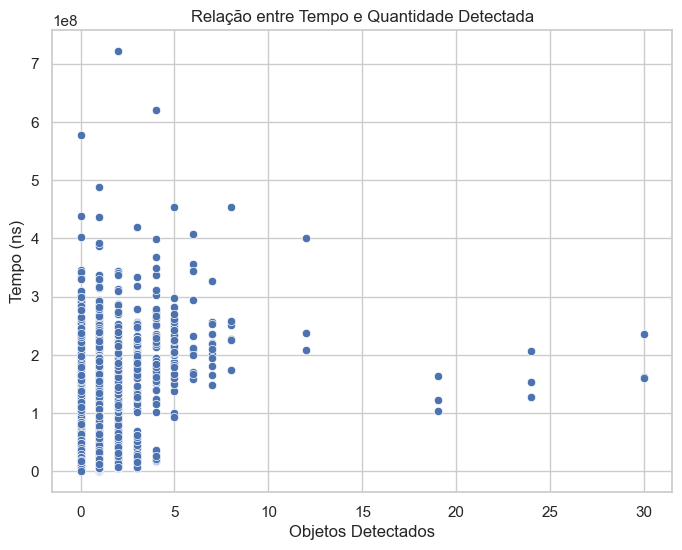

In [13]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='detected_count', y='time_ns')
plt.title("Relação entre Tempo e Quantidade Detectada")
plt.xlabel("Objetos Detectados")
plt.ylabel("Tempo (ns)")
plt.show()


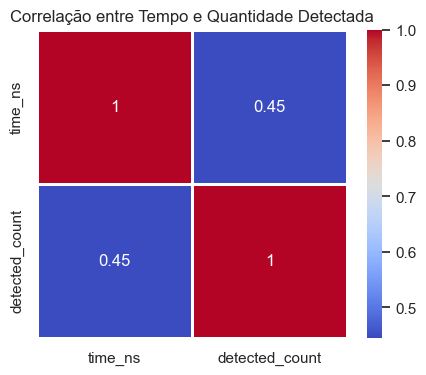

In [14]:
corr = df[['time_ns', 'detected_count']].corr()

plt.figure(figsize=(5,4))
sns.heatmap(corr, annot=True, cmap="coolwarm", linewidths=1)
plt.title("Correlação entre Tempo e Quantidade Detectada")
plt.show()


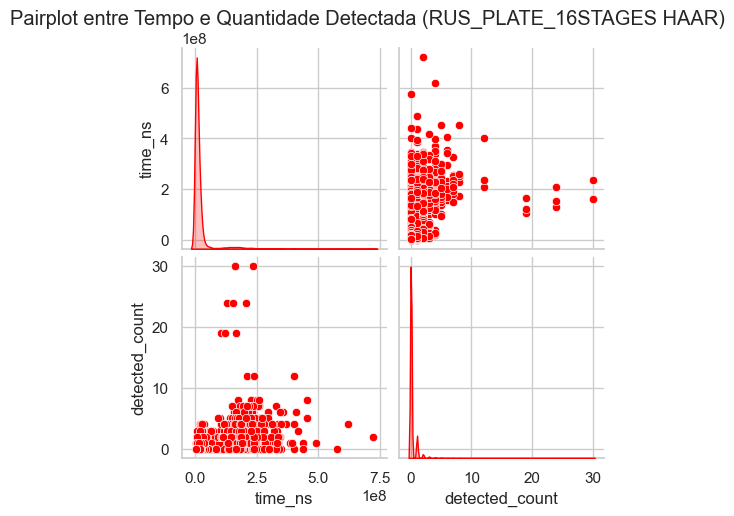

In [ ]:

g = sns.pairplot(df[['time_ns', 'detected_count']],
                    plot_kws={'color': 'blue'},
                    diag_kws={'color': 'blue'},
                     diag_kind='kde')
g.fig.suptitle("Pairplot entre Tempo e Quantidade Detectada (RUS_PLATE_16STAGES HAAR)", y=1.02)

plt.show()


In [16]:
df['z_time'] = (df['time_ns'] - df['time_ns'].mean()) / df['time_ns'].std()

outliers = df[df['z_time'].abs() > 3]

print("\n=== OUTLIERS DE TEMPO ===")
print(outliers[['file','dataset','time_ns','detected_count','z_time']])



=== OUTLIERS DE TEMPO ===
                                 file dataset    time_ns  detected_count  \
0                         1187019.jpg     DS1  145228400               1   
15                398000_labelled.jpg     DS1  158571900               0   
60                105000_labelled.jpg     DS1  188253500               0   
65               1187019_labelled.jpg     DS1  153944600               1   
72                100000_labelled.jpg     DS1  155762100               0   
...                               ...     ...        ...             ...   
16619   f9a571f7-EdGCgfyfO5qQN0O6.jpg     DS2  189163700               1   
16626  f9fed384-hHYc34U0YnmeDVRL.jpeg     DS2  226776000               3   
16694  fd9ee6e5-3TwDPMiea275UC0v.jpeg     DS2  165340600               0   
16713  fe6ef983-uWuZ3zV81xwYX3Pf.jpeg     DS2  299840400               0   
16726  ff4b034d-qDymZqnKTru5q4s2.jpeg     DS2  209631300               7   

         z_time  
0      3.010647  
15     3.325337  
60    

In [18]:
estat = {
    "media_time_ns": df['time_ns'].mean(),
    "mediana_time_ns": df['time_ns'].median(),
    "std_time_ns": df['time_ns'].std(),
    "media_detected": df['detected_count'].mean(),
    "mediana_detected": df['detected_count'].median(),
    "std_detected": df['detected_count'].std(),
}

print("\n=== ESTATÍSTICAS RESUMIDAS ===")
for k, v in estat.items():
    if "time" in k:
        # Converte Nanosegundos para Milissegundos (dividir por 1 milhão)
        # Ex: 15.000.000 ns -> 15.00 ms
        valor_ms = v / 1_000_000.0
        print(f"{k:<20}: {valor_ms:.4f} ms") # .4f = 4 casas decimais
    elif "detected" in k:
        # Quantidade de objetos detectados
        print(f"{k:<20}: {v:.4f} detecções/img")


=== ESTATÍSTICAS RESUMIDAS ===
media_time_ns       : 17.5710 ms
mediana_time_ns     : 6.0405 ms
std_time_ns         : 42.4020 ms
media_detected      : 0.1971 detecções/img
mediana_detected    : 0.0000 detecções/img
std_detected        : 0.8449 detecções/img


```
=== ESTATÍSTICAS RESUMIDAS  (RUS_PLATE_16STAGES HAAR) - PYTHON ===
media_time_ns       : 17.5710 ms
mediana_time_ns     : 6.0405 ms
std_time_ns         : 42.4020 ms
media_detected      : 0.1971 detecções/img
mediana_detected    : 0.0000 detecções/img
std_detected        : 0.8449 detecções/img